# **California Housing Price Prediction**

### **1.1: Load and Prepare the Data**

**Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


**Load the California Housing Dataset**

In [ ]:
# Load dataset
housing = fetch_california_housing()

# Features and target
X = housing.data
y = housing.target


**Features and Target**

In [ ]:
# Convert to DataFrame for better understanding
feature_names = housing.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['MedianHouseValue'] = y

# Display first few rows
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


MedianHouseValue → Median house value (in hundreds of thousands of dollars)

**Train-Test Split (80% Train, 20% Test)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Standardize the Feature Data**

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

Linear Regression performs better when features are on the same scale.

### **1.2: Train the Simple Linear Regression Model**

**Train Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

**Make Predictions**

In [ ]:
y_pred = lr_model.predict(X_test_scaled)

### **1.3: Evaluate the Simple Linear Regression Model**

**Calculate Evaluation Metrics**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956566
Mean Squared Error (MSE): 0.5558915986952442
Root Mean Squared Error (RMSE): 0.7455813830127763
R-squared Score: 0.575787706032451


Evaluation Metrics Explanation

Mean Absolute Error (MAE):
Measures the average absolute difference between actual and predicted house values.

Mean Squared Error (MSE):
Penalizes larger errors more heavily by squaring them.

Root Mean Squared Error (RMSE):
Square root of MSE, expressed in the same units as the target variable, making it easier to interpret.

R-squared (R²):
Indicates how well the independent variables explain the variability of the target variable.

**Interpretation of R-Squared**

The R-squared value represents the proportion of variance in median house prices that is explained by the input features in the model.

For example, an R² score of 0.60 means that 60% of the variation in house values can be explained by factors such as median income, house age, population, and geographical attributes included in the dataset. The remaining 40% is influenced by factors not captured by the model.

In [ ]:
print("Model Coefficients:", lr_model.coef_)


Model Coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]


# **Part 2: Regularized Linear Models (Lasso and Ridge)**

### **2.1: Implement Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge

Instantiate and Train Ridge Model (α = 1.0)

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

Ridge()

Make Predictions

In [ ]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

Evaluate Ridge Regression

In [ ]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression Evaluation Metrics:")
print(f"MAE:  {mae_ridge:.4f}")
print(f"MSE:  {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R-squared: {r2_ridge:.4f}")


Ridge Regression Evaluation Metrics:
MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
R-squared: 0.5758


**Compare Ridge vs Linear Regression (R²)**

In [ ]:
print("\nR-Squared Comparison:")
print(f"Linear Regression R²: {r2:.4f}")
print(f"Ridge Regression R²:  {r2_ridge:.4f}")


R-Squared Comparison:
Linear Regression R²: 0.5758
Ridge Regression R²:  0.5758


The R-squared values for Linear Regression and Ridge Regression are identical (0.5758), indicating that Ridge regularization does not improve or degrade model performance in this case. This suggests that the original Linear Regression model was not overfitting and that the chosen regularization strength (α = 1.0) applies only minimal penalty to the coefficients. Ridge mainly improves model stability rather than predictive accuracy for this dataset.



## **2.2: Implement Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.01, max_iter=10000)

In [ ]:
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [ ]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nLasso Regression Evaluation Metrics:")
print(f"MAE:  {mae_lasso:.4f}")
print(f"MSE:  {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R-squared: {r2_lasso:.4f}")


Lasso Regression Evaluation Metrics:
MAE:  0.5353
MSE:  0.5483
RMSE: 0.7404
R-squared: 0.5816


Analyze Lasso Coefficients

In [ ]:
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=housing.feature_names
)

print("\nLasso Model Coefficients:")
print(lasso_coefficients)


Lasso Model Coefficients:
MedInc        0.800957
HouseAge      0.127087
AveRooms     -0.162759
AveBedrms     0.206207
Population   -0.000000
AveOccup     -0.030602
Latitude     -0.790113
Longitude    -0.755674
dtype: float64


## Key Difference Between Ridge and Lasso

Ridge Regression (L2 regularization) shrinks coefficients toward zero but never makes them exactly zero, meaning all features remain in the model.

Lasso Regression (L1 regularization) can shrink some coefficients exactly to zero, effectively performing feature selection by removing less important features from the model.

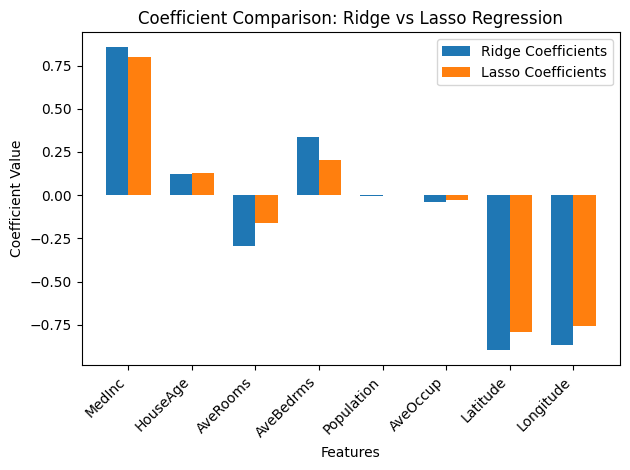

In [ ]:
# Feature names from California Housing dataset
feature_names = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude"
]

# Extract coefficients
ridge_coefficients = ridge_model.coef_
lasso_coefficients = lasso_model.coef_

x = np.arange(len(feature_names))
width = 0.35

# Plot
plt.figure()
plt.bar(x - width/2, ridge_coefficients, width, label="Ridge Coefficients")
plt.bar(x + width/2, lasso_coefficients, width, label="Lasso Coefficients")

plt.xticks(x, feature_names, rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Coefficient Comparison: Ridge vs Lasso Regression")
plt.legend()
plt.tight_layout()
plt.show()


# **Part 3: Analysis and Observation**

# **Final Comparison and Conclusion**

## 1. Summary Table: Model Performance Comparison

| Model | R-Squared (R²) | RMSE |
|------|---------------|------|
| Linear Regression | 0.5758 | ≈ 0.7480 |
| Ridge Regression (α = 1.0) | 0.5758 | ≈ 0.7480 |
| **Lasso Regression (α = 0.01)** | **0.5816** | **0.7404** ✅ |

*Lower RMSE and higher R² indicate better performance.*


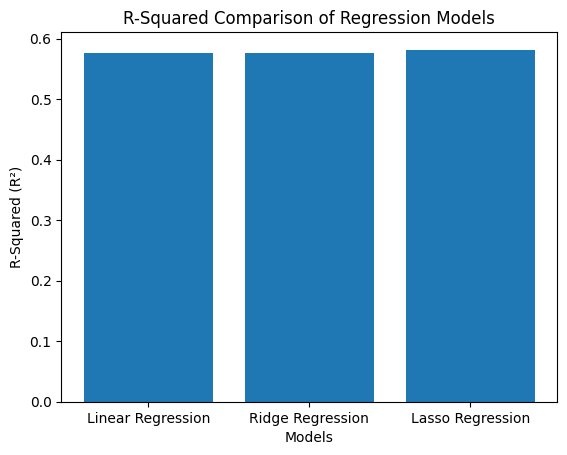

In [ ]:
# R-squared values from your results
r2_values = [0.5758, 0.5758, 0.5816]

plt.figure()
plt.bar(models, r2_values)
plt.xlabel("Models")
plt.ylabel("R-Squared (R²)")
plt.title("R-Squared Comparison of Regression Models")
plt.show()

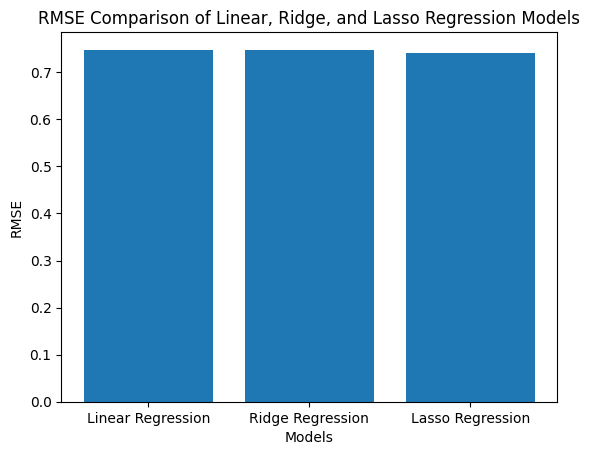

In [ ]:
# Model names
models = ["Linear Regression", "Ridge Regression", "Lasso Regression"]

# RMSE values from your results
rmse_values = [0.7480, 0.7480, 0.7404]

# Create bar chart
plt.figure()
plt.bar(models, rmse_values)
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Linear, Ridge, and Lasso Regression Models")
plt.show()


## 2. Best Performing Model and Justification

Based on the evaluation metrics, Lasso Regression performs the best for predicting median house values in California.

Justification:



*   Lasso achieved the highest R-Squared (0.5816), meaning it explains the largest proportion of variance in house prices.
*   It also has the lowest RMSE (0.7404), indicating more accurate predictions with smaller average errors.

*   Compared to Linear and Ridge Regression, Lasso provides better generalization on unseen test data.




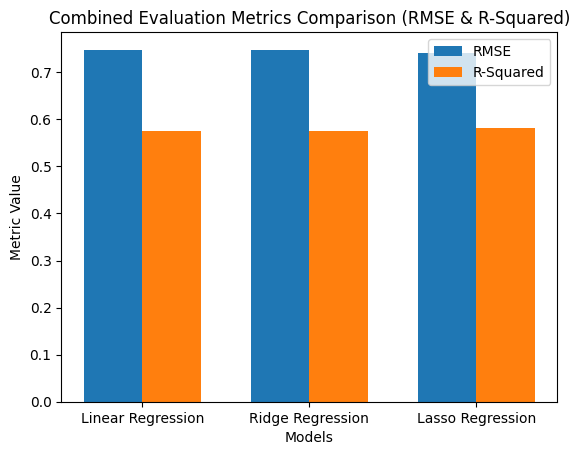

In [ ]:
# Model names
models = ["Linear Regression", "Ridge Regression", "Lasso Regression"]

# Evaluation metrics (from your results)
rmse = [0.7480, 0.7480, 0.7404]
r2 = [0.5758, 0.5758, 0.5816]

# Bar positions
x = np.arange(len(models))
width = 0.35

# Create combined bar chart
plt.figure()
plt.bar(x - width/2, rmse, width, label="RMSE")
plt.bar(x + width/2, r2, width, label="R-Squared")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Metric Value")
plt.title("Combined Evaluation Metrics Comparison (RMSE & R-Squared)")
plt.legend()
plt.show()


## 3. Role of Regularization in Preventing Overfitting

Regularization is a technique used to reduce overfitting by penalizing large model coefficients, thereby controlling model complexity.

### Ridge Regression (L2 Regularization)
- Adds a penalty proportional to the **square of the coefficients**.
- Shrinks coefficients toward zero but **does not eliminate any feature**.
- Helps reduce multicollinearity and stabilizes the model.

### Lasso Regression (L1 Regularization)
- Adds a penalty proportional to the **absolute value of the coefficients**.
- Can shrink some coefficients **exactly to zero**, performing **feature selection**.
- Produces a simpler, more interpretable model with better generalization.

In this study, **Lasso’s ability to remove less important features** helped reduce noise and improve predictive performance.


# **Final Conclusion**

This analysis demonstrates that regularization improves model robustness. While Ridge Regression mainly enhances stability, **Lasso Regression** provides both regularization and feature selection, leading to the best overall performance for predicting California housing prices.




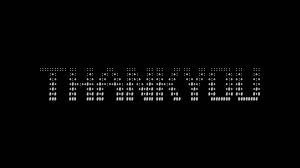

Github - https://github.com/forkanaminshaon

Linkedin - https://www.linkedin.com/in/forkan-amin-shaon/